## Equivalent Spectrum

Here, we discuss some additional details with the equivalent spectrum. Some of these details are expressed in our paper (Section IV.A.):
- Mark A. Bishop, Sean Oughton, Tulasi N. Parashar, Yvette C. Perrott; Direct power spectral density estimation from structure functions without Fourier transforms. Physics of Fluids 1 February 2026; 38 (2): 025107. https://doi.org/10.1063/5.0310561

We will go through the following steps in order and provide any updates we have made to the method.


Text(0.5, 1.0, 'Mock data')

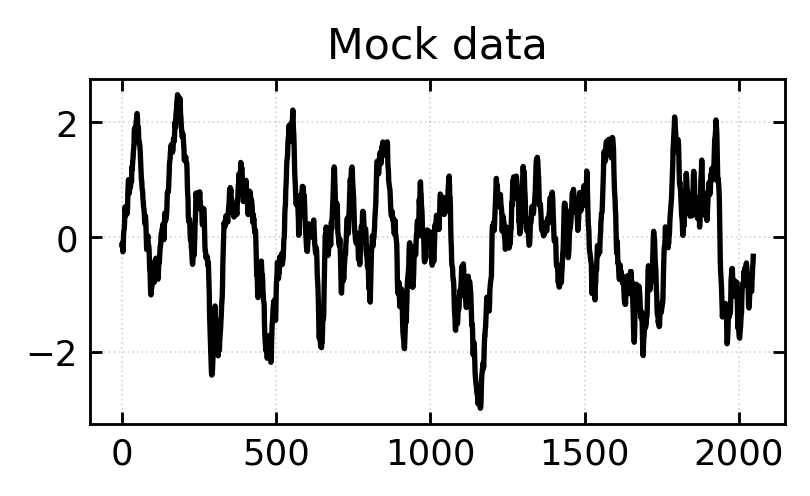

In [75]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
# modify_latex_rc()
# modify_latex_rc()

from kea.simulator import make_field

# Set number of grid points
N = 2048
# Number of dimensions (two-dimensional)
D = 1
# We have the same number of grid points in each dimension
grid_dims = (N,)*D

CUTOFF_SCALE = 15.
POWERLAW_INDEX = -8./3.
# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': POWERLAW_INDEX, 'cutoff_scale': CUTOFF_SCALE},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)

t = np.arange(N)

## Plot mock data
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.plot(t, field, linestyle='-', color='black')
pretty_axes(ax)
ax.set_title('Mock data')

- Step 1: Calculate the averaged second-order structure function: $\overline{S}_{D}(\ell)$
    - Calculation can be done using `kea`, or e.g., `fastSF`, `fluidSF`.
    - Most implementations of a SF calculation will natively stop at the maximum lag $\ell_\mathrm{max} \le \frac{N}{2} \Delta x$ -- this is the default value for `max_lag` in `kea.structure_function()`.

In the below example, we keep $\ell$ in code units, i.e., we display $n$ for $\ell = n \Delta x$.

Text(0.5, 0, 'Discrete Lag, $n$')

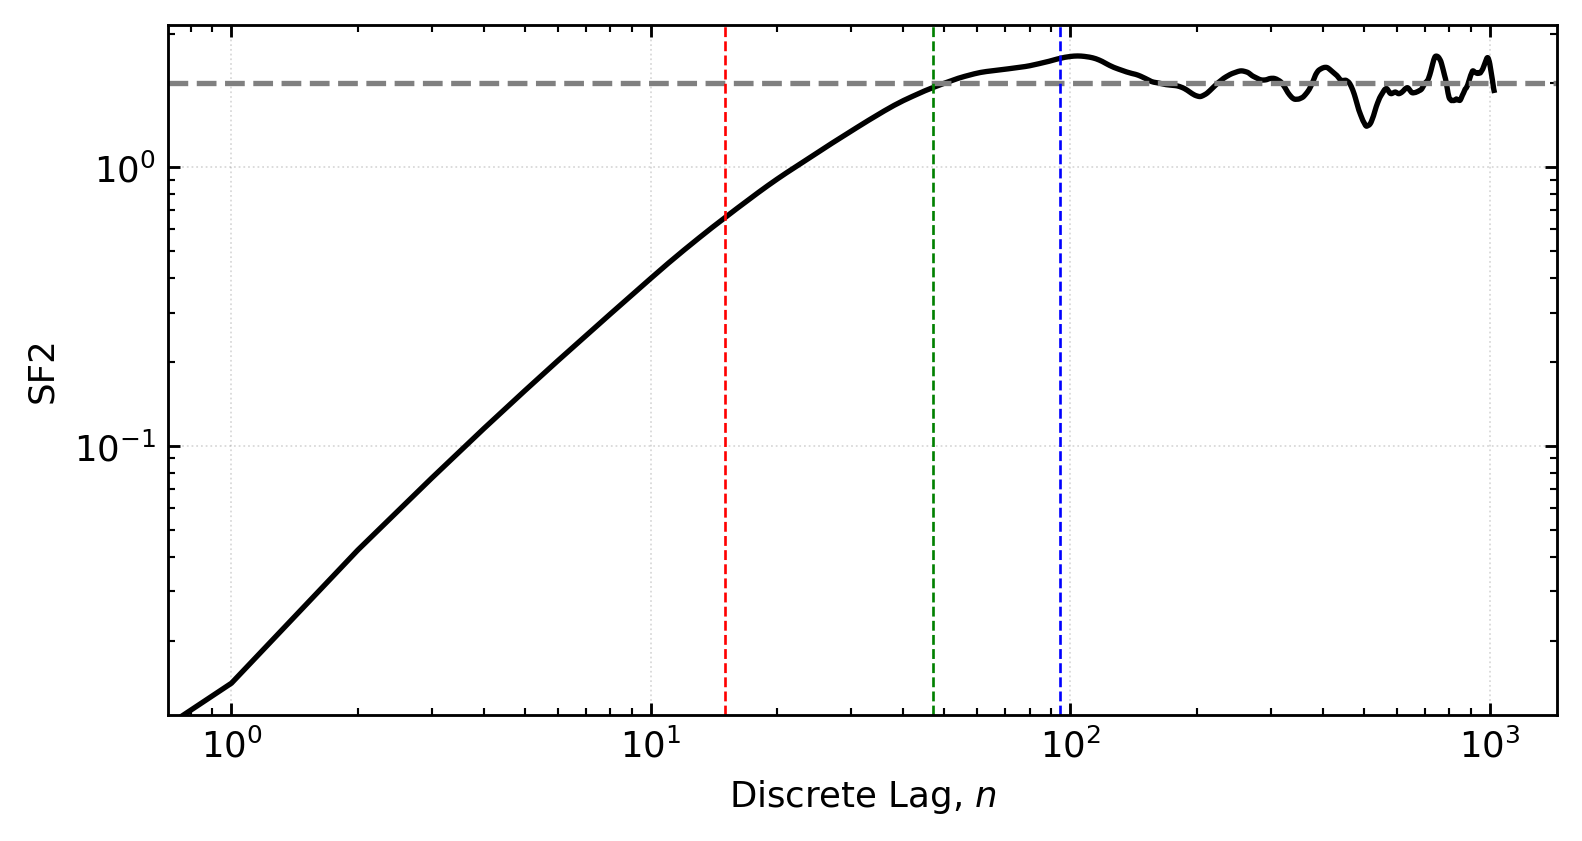

In [76]:
## Calculate the second order structure function
from kea.statistics.statfunc import structure_function
ell, sf2 = structure_function(field)
## Unpack the objects
ell = ell[:,0]
sf2 = sf2[:,0]

## Plot the second order structure function
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5), dpi=256)
ax.loglog(ell, sf2, linestyle='-', color='black')
ax.axhline(2.*np.nanvar(field), linestyle='--', color='gray')

ax.axvline(CUTOFF_SCALE, linestyle='--', color='red', linewidth=0.75)
ax.axvline(np.pi*CUTOFF_SCALE, linestyle='--', color='green', linewidth=0.75)
ax.axvline(2.*np.pi*CUTOFF_SCALE, linestyle='--', color='blue', linewidth=0.75)
pretty_axes(ax)
ax.set_ylabel('SF2')
ax.set_xlabel('Discrete Lag, $n$')

Notice that there is lots of oscillations about the 2 times the variance (horizontal gray dashed line) and notice that the SF isn't saturating at exactly the cutoff scale (vertical dashed red line). This already hints at complexities in the association between physical scale and wavenumber -- see, the other associations in the figure (vertical dashed green and blue) associated with $\pi$ and $2\pi$ times the cutoff scale.

Usually, $\overline{S}_{D}(\ell)$ has low amplitude-high frequency oscillations, which can propagate into the derivative(s) when estimating the equivalent spectrum. Therefore, we suggest binning, smoothing, or interpolating before moving onto the next step.

It is important to emphasize that over binning can lead to the loss of information.

We find it is best to bin in log-space -- so the resultant lags are evenly spaced in log-space.

We strongly recommend comparing the binned spectrum to the original spectrum to ensure there is minimal information loss.

/home/mark.bishop/Documents/Kea/src/kea/utils/fitting.py:39: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(x)
/home/mark.bishop/Documents/Kea/src/kea/utils/fitting.py:42: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(y)
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


Text(0.5, 1.0, 'Compare binning options for SF')

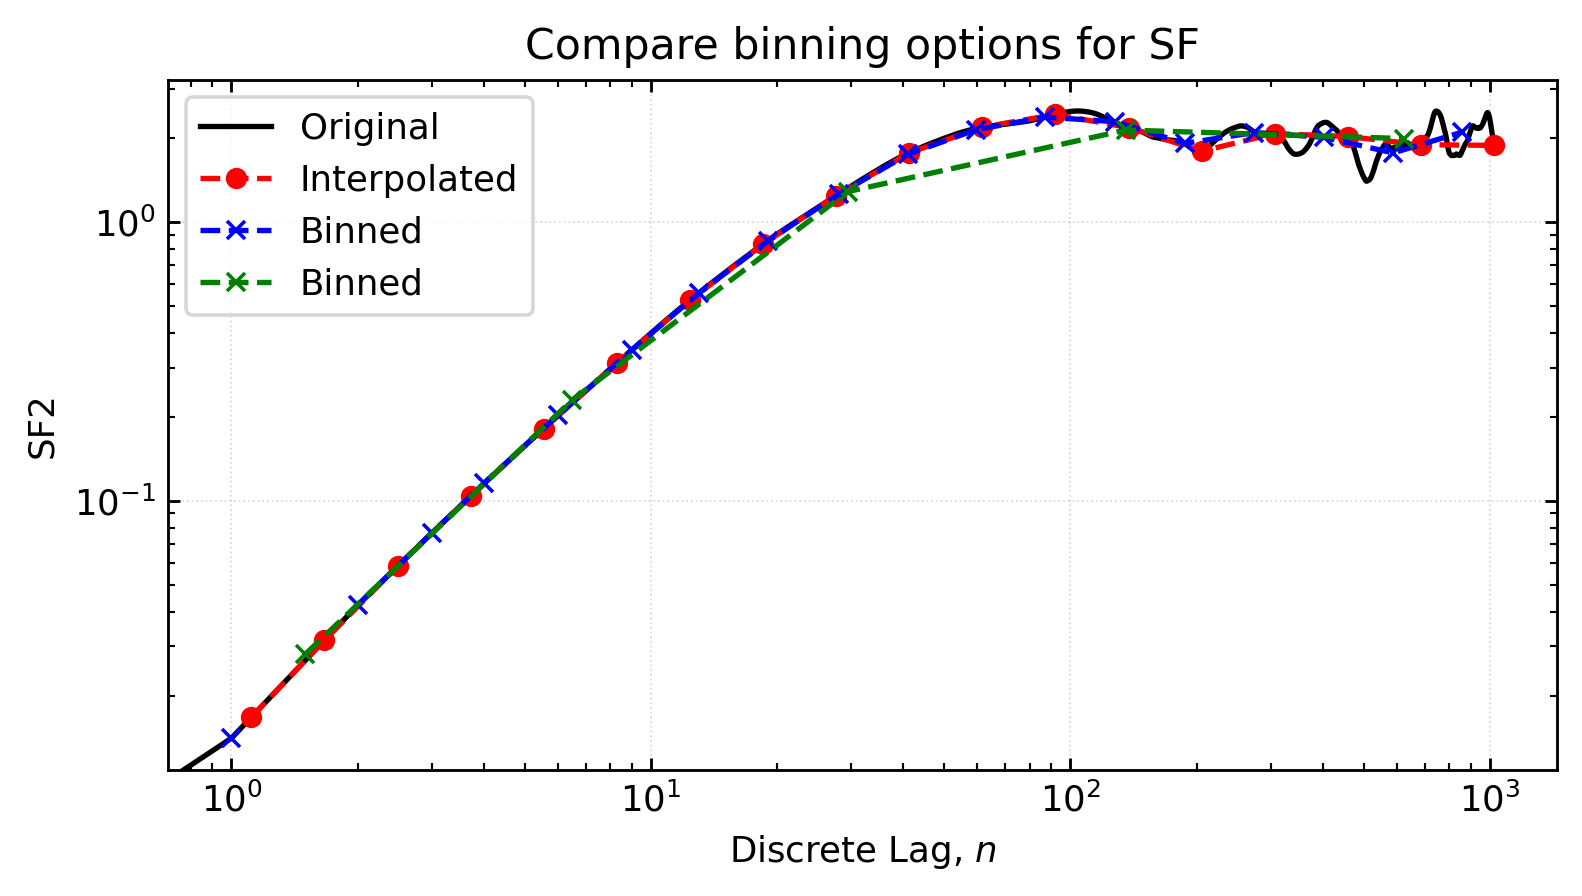

In [96]:
## Binning and interpolate the SF
from kea.utils import binning, fitting, set_fitting_mode
## We must ignore the ell=0 data point
ell_min = (ell[0]+ell[1])/2.
NUM_BINS = 20
## Interpolate
ell_i = np.exp(np.linspace(np.log(np.nanmin(ell_min)), np.log(np.nanmax(ell)), NUM_BINS))
set_fitting_mode(finite_differences=True)
ell_i, sf2_i = fitting.interpolate_1d_function(ell, sf2, ell_i, x_log=True, y_log=True)
## Interpolate using Gaussian process regression
# set_fitting_mode(gaussian_process=True)
# ell_g = np.exp(np.linspace(np.log(np.nanmin(ell_min)), np.log(np.nanmax(ell)), 5))
# ell_g, sf2_g = fitting.interpolate_1d_function(ell[1:], sf2[1:], ell_g, x_log=True, y_log=True)
## Bin the data
ell_b, sf2_b, _ = binning.bin_data(ell, sf2, bin_func=np.nanmean, cut_excess=True, nan_small=False, bin_loc='true_center', log_space=True, num_bins=NUM_BINS, min_bin=ell_min, max_bin=np.nanmax(ell))
ell_b2, sf2_b2, _ = binning.bin_data(ell, sf2, bin_func=np.nanmean, cut_excess=True, nan_small=False, bin_loc='true_center', log_space=True, num_bins=5, min_bin=ell_min, max_bin=np.nanmax(ell))


## Plot the binned functions
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5), dpi=256)
ax.loglog(ell, sf2, linestyle='-', color='black', label='Original')
ax.plot(ell_i, sf2_i, linestyle='--', color='red', marker='o', markersize=5., label='Interpolated')
# ax.plot(ell_g, sf2_g, linestyle='--', color='green', marker='o', markersize=5., label='GP Interpolated')
ax.plot(ell_b, sf2_b, linestyle='--', color='blue', marker='x', markersize=5., label='Binned')
ax.plot(ell_b2, sf2_b2, linestyle='--', color='green', marker='x', markersize=5., label='Binned')
ax.legend()
pretty_axes(ax)
ax.set_ylabel('SF2')
ax.set_xlabel('Discrete Lag, $n$')
ax.set_title('Compare binning options for SF')

For this example, the only behaviour we are smoothing out is the large $n$ fluctuations. Reducing the number of bins/interpolating to fewer points would reduce these fluctuations further. However, there is a trade-off, we still wish to retain the behaviour of the slope. For example, looking at the green binned curve, we are losing some information to make the large $n$ behaviour flat.

- Step 2: Create the "uncorrected" estimate.

In [88]:
def _sf_to_spectrum(
        ell: np.ndarray,
        sf2: np.ndarray,
        b: float):
    """_sf_to_spectrum(ell, sf2, phys_dims, grid_dims, b, ko)\n

    Estimates the Fourier spectrum using the (derivative of the) structure function

    Args:
        ell (np.ndarray): Lags
        sf2 (np.ndarray): Angle-averaged second order structure function
        b (float): Wavenumber bias factor
        ko (np.ndarray/None): Discrete wavenumbers for FFT

    Returns:
        (np.ndarray, np.ndarray): Equivalent wavenumbers and uncorrected equivalent spectrum
    """
    ell, dSdell = fitting.get_derivative(ell, sf2, ell, x_log=True, y_log=True)
    BfekS = (1./2.) * ell**2 * dSdell / b
    ke = b / ell
    ke, BfekS = ke[::-1], BfekS[::-1]
    return ke, BfekS

We have the options of estimating the ESF using finite-differences and Gaussian process regression methods.

/home/mark.bishop/Documents/Kea/src/kea/utils/fitting.py:39: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(x)
/home/mark.bishop/Documents/Kea/src/kea/utils/fitting.py:40: RuntimeWarning: divide by zero encountered in log10
  x_interp = np.log10(x_interp)
/home/mark.bishop/Documents/Kea/src/kea/utils/fitting.py:42: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(y)
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/interpolate/_interpolate.py:500: RuntimeWarning: invalid value encountered in subtract
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/home/mark.bishop/Documents/Kea/src/kea/statistics/spectra/equiv_spectrum.py:73: RuntimeWarning: divide by zero encountered in divide
  ke = b / ell
/home/mark.bishop/miniconda3/e

Text(0.5, 1.0, 'Compare binning options for ESF')

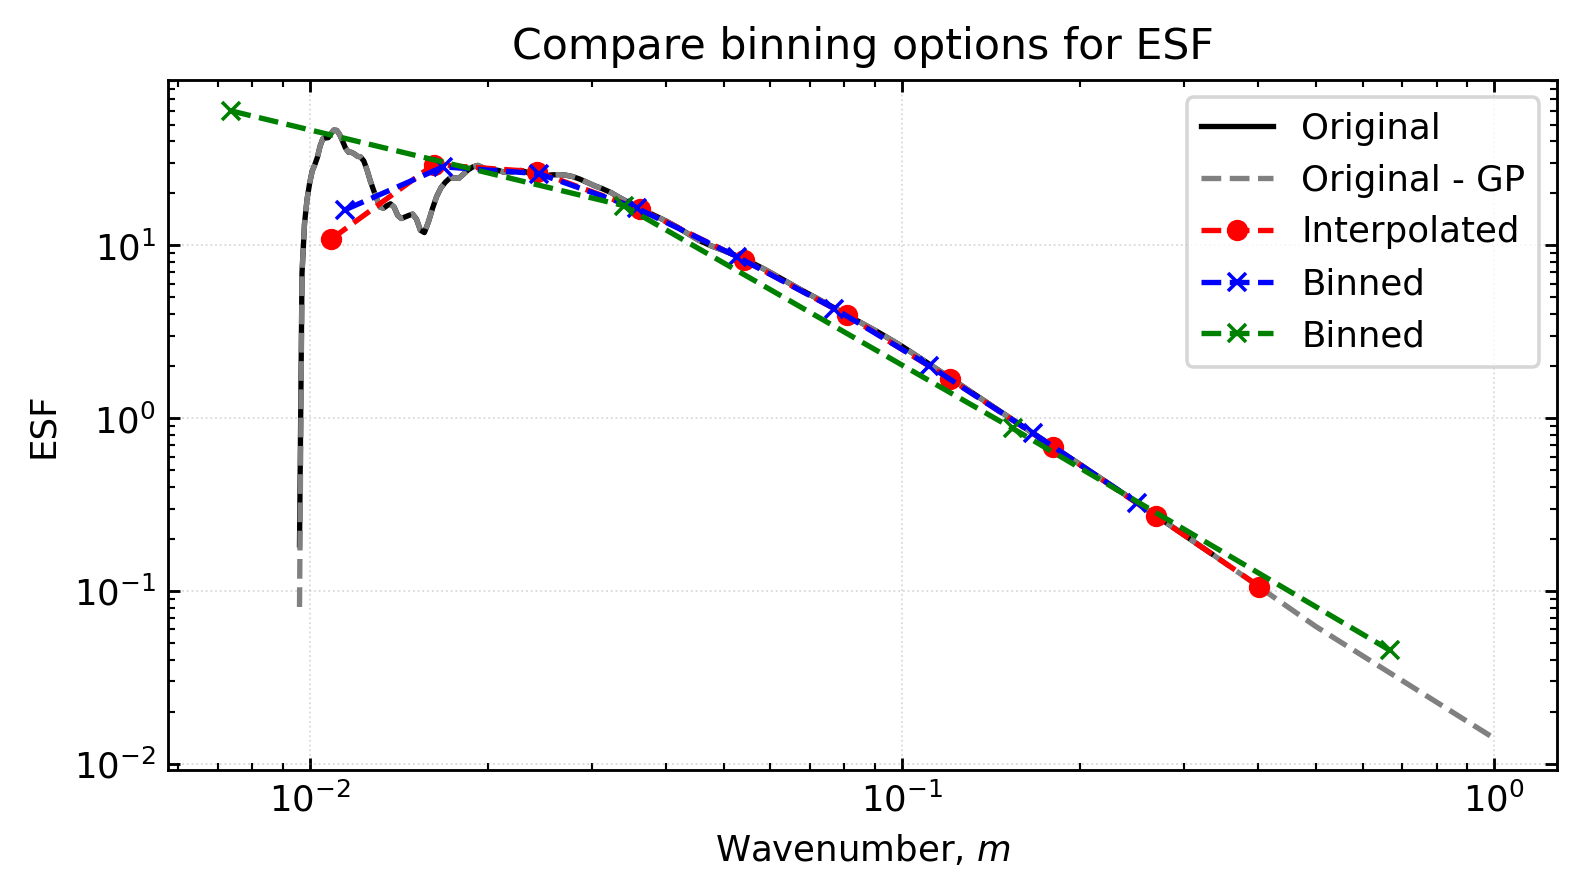

In [97]:
# from kea.statistics.spectra.equiv_spectrum import _sf_to_spectrum
set_fitting_mode(finite_differences=True)
ke, feke = _sf_to_spectrum(ell, sf2, 1.)
ke_i, feke_i = _sf_to_spectrum(ell_i, sf2_i, 1.)
ke_b, feke_b = _sf_to_spectrum(ell_b, sf2_b, 1.)
ke_b2, feke_b2 = _sf_to_spectrum(ell_b2, sf2_b2, 1.)
set_fitting_mode(gaussian_process=True)
ke_gp, feke_gp = _sf_to_spectrum(ell[1:], sf2[1:], 1.)

## Plot the binned functions
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5), dpi=256)
ax.loglog(ke, feke, linestyle='-', color='black', label='Original')
ax.loglog(ke_gp, feke_gp, linestyle='--', color='gray', label='Original - GP')
ax.plot(ke_i, feke_i, linestyle='--', color='red', marker='o', markersize=5., label='Interpolated')
# ax.plot(ell_g, feke_i, linestyle='--', color='green', marker='o', markersize=5., label='GP Interpolated')
ax.plot(ke_b, feke_b, linestyle='--', color='blue', marker='x', markersize=5., label='Binned')
ax.plot(ke_b2, feke_b2, linestyle='--', color='green', marker='x', markersize=5., label='Binned')
ax.legend()
pretty_axes(ax)
ax.set_ylabel('ESF')
ax.set_xlabel('Wavenumber, $m$')
ax.set_title('Compare binning options for ESF')


Examining above, we see that the Original ESF at small $m$ fluctuates significantly whereas the interpolated and binned ESF are better behaved. However, note for signicantly small $m$ ($\le 10^{-2}$) the fluctuations persist for all methods. This is due to the changes in slope fluctuating about the variance limit.

For the green curve (that corresponds to excessive binning), there is information loss and the slope appears to be different.

Now, we examine the result of using different $b$ factors.

<>:11: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:11: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:12: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

Text(0.5, 1.0, 'Compare different $b$ factor estimations')

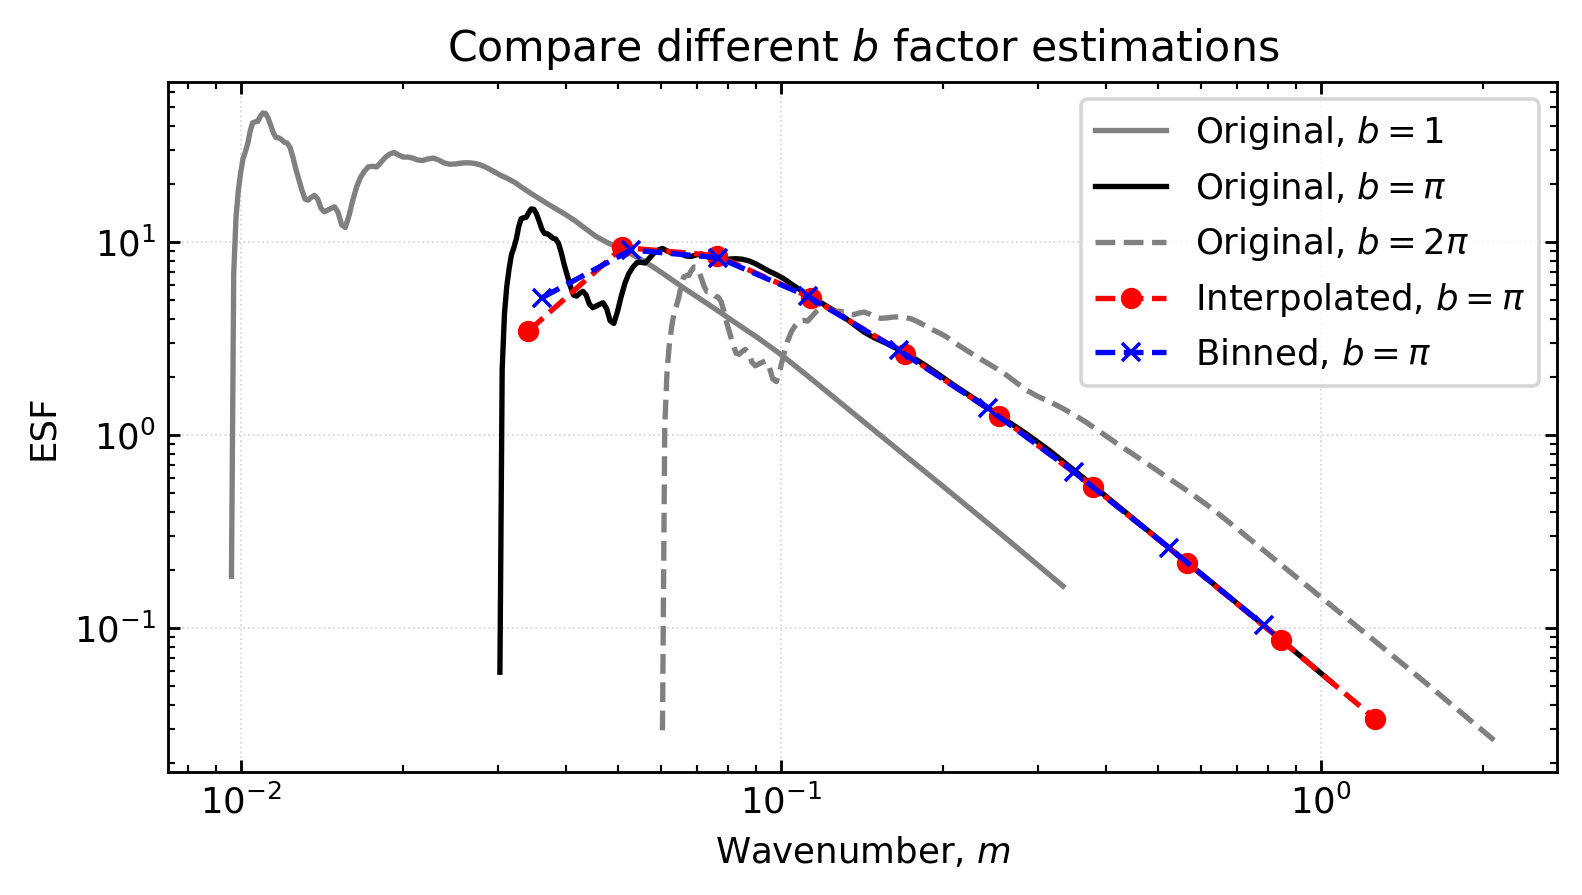

In [91]:
from kea.statistics.spectra.equiv_spectrum import _sf_to_spectrum
ke_1, feke_1 = _sf_to_spectrum(ell, sf2, 1.)
ke, feke = _sf_to_spectrum(ell, sf2, np.pi)
ke_2pi, feke_2pi = _sf_to_spectrum(ell, sf2, 2.*np.pi)
ke_i, feke_i = _sf_to_spectrum(ell_i, sf2_i, np.pi)
ke_b, feke_b = _sf_to_spectrum(ell_b, sf2_b, np.pi)

## Plot the binned functions
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5), dpi=256)
ax.loglog(ke_1, feke_1, linestyle='-', color='gray', label='Original, $b=1$')
ax.loglog(ke, feke, linestyle='-', color='black', label='Original, $b=\pi$')
ax.loglog(ke_2pi, feke_2pi, linestyle='--', color='gray', label='Original, $b=2\pi$')
ax.plot(ke_i, feke_i, linestyle='--', color='red', marker='o', markersize=5., label='Interpolated, $b=\pi$')
# ax.plot(ell_g, feke_i, linestyle='--', color='green', marker='o', markersize=5., label='GP Interpolated')
ax.plot(ke_b, feke_b, linestyle='--', color='blue', marker='x', markersize=5., label='Binned, $b=\pi$')
ax.legend()
pretty_axes(ax)
ax.set_ylabel('ESF')
ax.set_xlabel('Wavenumber, $m$')
ax.set_title('Compare different $b$ factor estimations')


Looking at above; comparing the ESF for different $b$ factors, we see that there are significant different for difference $b$ factors.

The remaining steps follows the principles that we have discussed above.